Neural online parameter control of a mode-locked Laser
---
In this notebook, we use a neural network for online parameter control of a mode-locked Laser. The Laser is described by a system of coupled, non-linear Schrödinger equations: \begin{align}i\dfrac{\partial u}{\partial z} + \dfrac{D}{2}\dfrac{\partial^2u}{\partial t^2} - Ku + (\vert u \vert^2 + A\vert v \vert^2)u + B v^2 u^\dagger & = i g(z)\left(1 + \Omega \dfrac{\partial^2}{\partial t^2}\right)u - i \Gamma u \\ i\dfrac{\partial v}{\partial z} + \dfrac{D}{2}\dfrac{\partial^2v}{\partial t^2} + Kv + (A\vert u \vert^2 + \vert v \vert^2)v + B u^2 v^\dagger & = i g(z)\left(1 + \Omega \dfrac{\partial^2}{\partial t^2}\right)v - i \Gamma v.\end{align} Here, $D$ is the chromatic dispersion, $K$ is the birefringence which determines the relative phase velocity difference between $u$ and $v$, and $A$ and $B$ are non-linear coupling parameters satisfying $A+B=1$. We follow Kutz & Brunton (2015) and set $A=2/3$ and $B=1/3$. The right-hand side of the above equation models dissipation due to the gain $g(z)$, as well as cavity losses due to linear attenuation of the field: $\Gamma$ models the distributed loss of the fibre laser cavity due to output coupling. The gain $g(z)$ is given by
\begin{equation*}
    g(z) = \dfrac{2g_0}{1 + \frac{1}{E_0}\int_{-\infty}^{+\infty} (\vert u \vert^2 + \vert v \vert^2) \mathrm{d}t},
\end{equation*}
with $g_0$ the pumping strength and $E_0$ the cavity saturation energy. The integrand $\vert u \vert^2 + \vert v \vert^2$ is the total energy of the beam. The variable $z$ is the system coordinate parametrising the position along the fibre, which has total length $L$.

The equations are solved by performing a Fourier transform in $t$ and then solving the resulting system of ODEs in $x$ using a time-stepper.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import tqdm
import torch
from torch.fft import fft

# Local imports
import sys
import os
from os.path import dirname as up
from dantro._import_tools import import_module_from_path
root = up(os.path.dirname(os.getcwd()))
sys.path.append(root)
include = import_module_from_path(mod_path=root, mod_str="include")
model_plots = import_module_from_path(mod_path=root, mod_str="model_plots")
from include import neural_net, colors
from model import Laser_cavity

# Use a custom style sheet
plt.style.use('model_plots.plot_style')
page_width = 6.47453 # Fixed page width for Latex integration
%matplotlib inline

# Create a ColorManager
from dantro.plot.utils import ColorManager
cm_GrYeOr = ColorManager(
    cmap={'continuous': True, 'from_values': {0: 'black', 0.5: colors['c_darkblue'], 0.95: colors['c_lightblue'], 1: 'white'}},
)

REMARK   logging           Configuring a linear colormap 'from values'. 


## Set up the laser and neural network
First, we combine the laser and neural network objects into a single class, allowing for simpler handling. The Laser cavity object is defined in the `model.py` file, sitting alongside this notebook.

In [2]:
class Laser_NN:
    def __init__(self, *, neural_net: neural_net.FeedForwardNN, laser: Laser_cavity):
        """Combined Laser cavity object together with a neural network used for online angle calibration. The objective function is the energy divided by the
        kurtosis (fourth moment) of the beam's spectrum, used to create a high-energy, mode-locked Laser beam.

        :param neural_net: NeuralNet object, used for calibration
        :param laser: Laser_cavity object
        """
        self.neural_net = neural_net
        self.neural_net.optimizer.zero_grad()
        self.laser = laser

        # Objective to be maximised
        self.objective = torch.tensor(0.0)


    def initialise_laser(self, initial_condition: torch.Tensor, n_round_trips: int = 100, *, method: str = None) -> None:
        """ Initialises the laser to a given initial condition.

        :param initial_condition: initial condition to use
        :param n_round_trips: number of round trips to simulate
        :param method: ODE solver method, passed to `torchdiffeq.odeint`. Default is 'implicit_adams'
        """

        # Set the initial state of the laser, given in real space
        self.laser.set_state(initial_condition, set_init=True)

        # Calculate the initial energy
        self.laser.set_energy()

        # Perform n round trips
        for _ in (pbar := tqdm.trange(n_round_trips)):
            self.laser.round_trip(method=method)
            pbar.set_description(f"Initialising: J = {(self.laser.energy / self.laser.kurtosis):>.4g}")

    def get_NN_input(self) -> torch.Tensor:
        """ Calculates the input to the neural network, given by the Laser's spectrum."""
        spec = torch.cat([torch.abs(fft(self.laser.state[0]))**2, torch.abs(fft(self.laser.state[1]))**2])
        return spec - spec.mean()

    def set_parameters_from_NN(self) -> None:
        """ Set the parameters of model to the output of the neural network. By default, these are tracked through the
        numerical solver and gradients can then be used to optimise the neural network."""

        # Make a prediction. The neural network must output values in [-1, 1] (-90 to +90).
        prediction = torch.pi * self.neural_net(self.get_NN_input()).flatten()

        # Set the transformation matrix of the laser using the current prediction
        self.laser.set_alpha(prediction)

    def objective_function(self) -> torch.Tensor:
        """" Calculate the objective function of the laser, which is the energy divided by the fourth moment
         of the Fourier spectrum """
        return self.laser.solver.energy(self.laser.state) / self.laser.solver.kurtosis(self.laser.state)

    def perform_step(self):
        """ Performs a single gradient descent step."""
        loss = -self.objective_function() # We want to maximise the objective
        loss.backward()
        self.neural_net.optimizer.step()
        self.neural_net.optimizer.zero_grad()

        self.objective = -loss.detach().clone()
        self.laser.clear_gradients()

We initialise the laser using a fixed angles and an initial distribution.

In [3]:
# Initial angles
alpha_0 = torch.tensor([torch.pi/6, torch.pi/6, torch.pi/5, torch.pi/4]).float()

In [4]:
laser = Laser_cavity(
    parameters=dict(D=1, K=0.1, E0=1, Omega=0.1, g0=0.3, Gamma=0.2, A=1/3, B=2/3),
    t=torch.linspace(-25, +25, 256),
    z=torch.tensor([0, 0.5, 1]),
    alpha=alpha_0 # initial angles
)

NN = neural_net.FeedForwardNN(
    input_size=2 * len(laser.solver.t), # Beam spectrum
    output_size=4, # four angles
    num_layers=3,
    nodes_per_layer=dict(default=20),
    biases=dict(default=None),
    activation_funcs=dict(default='sigmoid', layer_specific={-1: 'sigmoid'}),
    optimizer='Adam',
    lr=0.001,
)

# Set up the joint class
model = Laser_NN(laser=laser, neural_net=NN)
model.initialise_laser(torch.stack([torch.cosh(model.laser.solver.t) ** (-1), 0.2 * torch.cosh(model.laser.solver.t) ** (-1)]).cfloat(), n_round_trips=1)

Initialising: J = 2.642: 100%|██████████| 1/1 [00:00<00:00, 52.09it/s]


Then, we let the Laser run, allowing it to reach an initial mode-locked state.

In [5]:
init_state, init_energy, init_kurtosis = [], [], []

In [6]:
# Initialise
for _ in tqdm.trange(16000):
    model.laser.round_trip(method=None)
    init_state.append(model.laser.state)
    init_energy.append(model.laser.energy)
    init_kurtosis.append(model.laser.kurtosis)
steady_init_state = model.laser.state

100%|██████████| 16000/16000 [02:56<00:00, 90.74it/s] 


Store this steady state as an initial condition to which we can return when comparing the Laser performance with and without the neural controller.

In [7]:
model.laser.set_state(steady_init_state)

Let's plot the beam's intensity in Fourier space as it initialises:

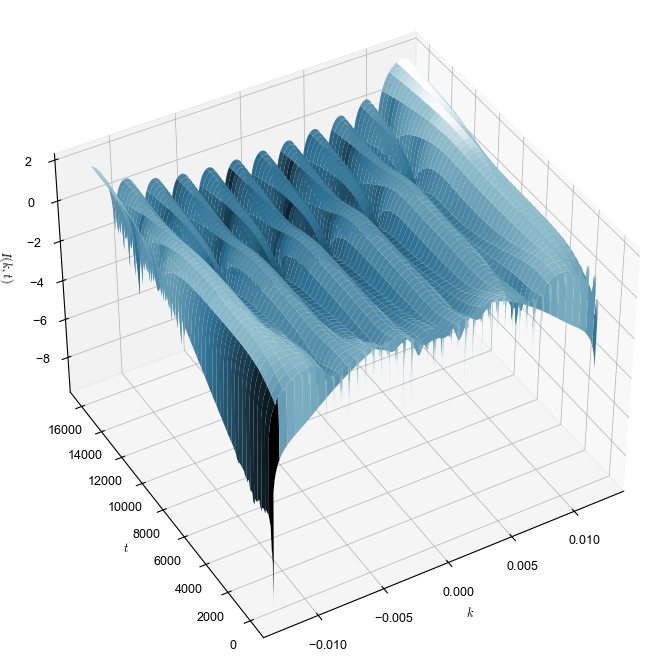

In [8]:
fig, ax = plt.subplots(subplot_kw=dict(projection='3d'), gridspec_kw={'hspace': 0.2, 'wspace': 0.1}, figsize=(page_width, page_width))
x, y = np.meshgrid(model.laser.solver.k_sorted, torch.arange(len(init_state[10:])))
ax.plot_surface(x, y, torch.log10(torch.fft.fftshift(fft(torch.stack(init_state)[10:, 0, :]), dim=-1).abs()**2 + torch.fft.fftshift(fft(torch.stack(init_state)[10:, 1, :]), dim=-1).abs()**2 + 1e-12), cmap=cm_GrYeOr.cmap, axlim_clip=True)
ax.set(xlabel='$k$', ylabel='$t$', zlabel='$I(k, t)$')
ax.view_init(elev=40, azim=240)

We can see that, over time, we obtain a regular frequency comb, indicating a mode-locked state:

[Text(0.5, 1.0, 'Spectral intensity $I(k)$ (log-scaled)')]

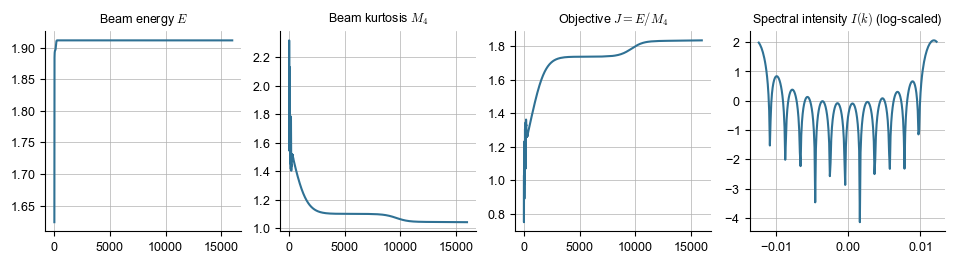

In [9]:
fig, axs = plt.subplots(ncols=4, figsize=(9, 2))
axs[0].plot(init_energy)
axs[0].set(title='Beam energy $E$')
axs[1].plot(init_kurtosis)
axs[1].set(title='Beam kurtosis $M_4$')
axs[2].plot(torch.stack(init_energy)/torch.stack(init_kurtosis))
axs[2].set(title='Objective $J = E / M_4$')
axs[3].plot(model.laser.solver.k_sorted,
            torch.log10(torch.fft.fftshift(fft(torch.stack(init_state)[-1, 0, :])).abs()**2 + torch.fft.fftshift(fft(torch.stack(init_state)[-1, 1, :])).abs()**2 + 1e-12))
axs[3].set(title="Spectral intensity $I(k)$ (log-scaled)")

Now we initialise the neural network to output the angles:

In [18]:
# Initialise the NN to output the initial angles
spec = model.get_NN_input()
for _ in (pbar := tqdm.trange(1000)):
    pred = torch.pi * model.neural_net(spec)
    loss = torch.nn.functional.mse_loss(pred, alpha_0)
    loss.backward()
    model.neural_net.optimizer.step()
    model.neural_net.optimizer.zero_grad()
    pbar.set_description(f"Loss: {loss.detach()}")

print(f"Neural network output: {pred * 180/torch.pi}")

Loss: 0.0: 100%|██████████| 1000/1000 [00:01<00:00, 845.74it/s]                   


Neural network output: tensor([30., 30., 36., 45.], grad_fn=<DivBackward0>)


## Optimise the angles
Before the online calibration begins, let us first optimise the angles to obtain the best possible laser state:

In [12]:
# Optimise the angles
state_calib, energy_calib, kurtosis_calib = [], [], []
for i in (pbar := tqdm.trange(100)):

    # Update the angles
    model.set_parameters_from_NN()

    # Perform n round trips after each adjustment to achieve equilibrium
    for _ in range(10):
        model.laser.round_trip()
        state_calib.append(model.laser.state.clone().detach())
        energy_calib.append(model.laser.energy.clone().detach())
        kurtosis_calib.append(model.laser.kurtosis.clone().detach())

    # Adjust the angles
    model.perform_step()

    pbar.set_description(f"J: {model.laser.energy/model.laser.kurtosis:>.4g}, K: {model.laser.solver.parameters['K']:>.4g}, Angles: {', '.join([f'{(a/torch.pi * 180):>.4g}º' for a in model.laser._alpha.numpy().tolist()])}")

J: 1.919, K: 0.1, Angles: 32.01º, 26.45º, 37.4º, 45.04º: 100%|██████████| 100/100 [00:31<00:00,  3.18it/s]


Let's again plot the beam intensity during this calibration period:

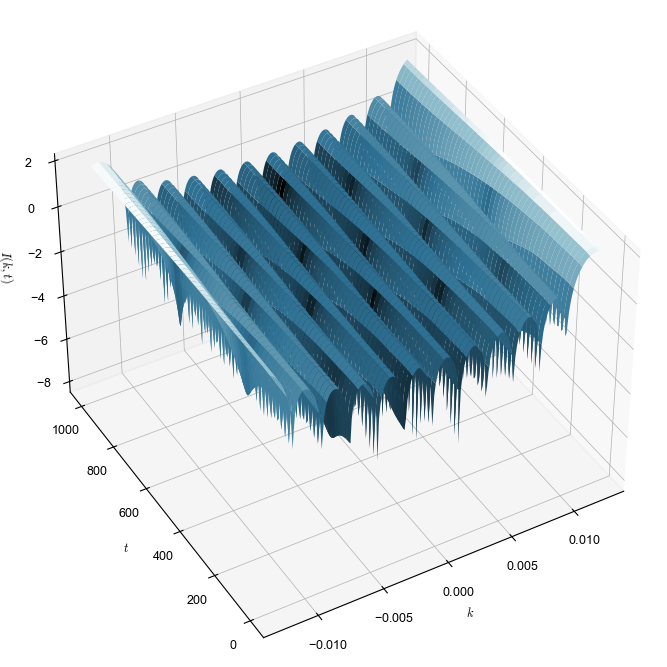

In [13]:
# Plot the beam intensity as it initialises
fig, ax = plt.subplots(subplot_kw=dict(projection='3d'), gridspec_kw={'hspace': 0.2, 'wspace': 0.1}, figsize=(page_width, page_width))
x, y = np.meshgrid(model.laser.solver.k_sorted, torch.arange(len(state_calib[:])))
ax.plot_surface(x, y, torch.log10(torch.fft.fftshift(fft(torch.stack(state_calib)[:, 0, :]), dim=-1).abs()**2 + torch.fft.fftshift(fft(torch.stack(state_calib)[:, 1, :]), dim=-1).abs()**2 + 1e-12), cmap=cm_GrYeOr.cmap, axlim_clip=True)
ax.set(xlabel='$k$', ylabel='$t$', zlabel='$I(k, t)$')
ax.view_init(elev=40, azim=240)

It hasn't changed much, but the beam energy and objective should have increased a little:

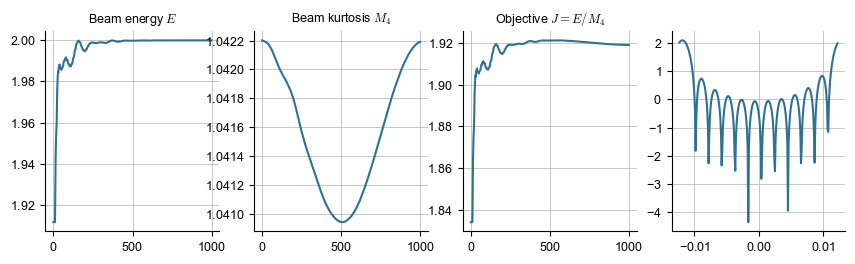

In [14]:
fig, axs = plt.subplots(ncols=4, figsize=(8, 2))
axs[0].plot(energy_calib)
axs[0].set(title='Beam energy $E$')
axs[1].plot(kurtosis_calib)
axs[1].set(title='Beam kurtosis $M_4$')
axs[2].plot(torch.stack(energy_calib)/torch.stack(kurtosis_calib))
axs[2].set(title='Objective $J = E / M_4$')
axs[3].plot(model.laser.solver.k_sorted,
            torch.log10(torch.fft.fftshift(fft(torch.stack(state_calib)[-1, 0, :])).abs()**2 + torch.fft.fftshift(fft(torch.stack(state_calib)[-1, 1, :])).abs()**2 + 1e-12))

In [15]:
# Let's again store this state so we can return to it later
optimised_init_state = model.laser.state.clone()

# Online parameter control
## Create a birefringence time series
First, we create a simulated birefringence time series, simulating a slow, meandering birefringence time series $K(t)$. We use a Brownian motion, clipped to [-0.3, +0.3]. For reproducibility, we load the time series used in the original experiments, but of course this is not necessary.

In [38]:
# K = [torch.tensor(0.1)]
# for _ in range(1500):
#     K.append(torch.clip(torch.normal(K[-1], torch.tensor(1e-2)), -0.3, +0.3))
# K = torch.stack(K)
#
# # torch.save(K, "K.pt")
K = torch.load("../../data/Laser/K.pt", weights_only=True).float()

[Text(0, 0.5, 'Birefringence $K$')]

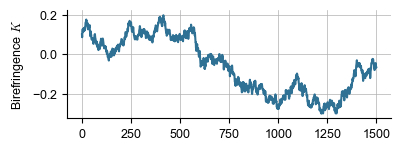

In [21]:
fig, ax = plt.subplots(figsize=(page_width/2, page_width/6))
ax.plot(K)
ax.set(xlabel='Simulated time $t$', ylabel='Birefringence $K$')

## Simulate the laser behaviour without controls
Now, we simulate the laser behaviour without any controls. The mode-locked stability quickly decreases over time.

In [34]:
model.laser.set_state(optimised_init_state)
model.laser.clear_gradients()

In [35]:
# Run the model without the control
objective_no_control = []
for i in (pbar := tqdm.trange(len(K))):

    # Vary the birefringence
    model.laser.solver.set_parameter(dict(K=K[i]))

    # Perform 10 round trips to achieve equilibrium
    for _ in range(10):
        model.laser.round_trip()

    # Write the data
    objective_no_control.append((model.laser.energy/model.laser.kurtosis).detach())
    pbar.set_description(f"E: {model.laser.energy:>.4g}, M_4: {model.laser.kurtosis:>.4g}, J: {model.laser.energy/model.laser.kurtosis:>.4g}, K: {model.laser.solver.parameters['K']:>.4g}")

E: 1.912, M_4: 1.064, J: 1.797, K: -0.06684: 100%|██████████| 1501/1501 [05:00<00:00,  4.99it/s] 


## Add a control
Now, we add a control. The neural network receives the beam's spectrum as input and is tasked with stabilising the objective function by adjusting the angles.

In [24]:
model.laser.set_state(optimised_init_state)
model.laser.clear_gradients()

In [25]:
objective_with_control = []
angles = []

In [26]:
# Optimise the angles
for i in (pbar := tqdm.trange(len(K))):

    model.laser.solver.set_parameter(dict(K=K[i]))

    # Update the angles
    for _ in range(10):

        # Set the parameters
        model.set_parameters_from_NN()

        # Perform n round trips to achieve equilibrium
        for __ in range(10):
            model.laser.round_trip()

        # Adjust the angles
        model.perform_step()

    objective_with_control.append((model.laser.energy/model.laser.kurtosis).detach())
    angles.append(model.laser._alpha.detach())
    pbar.set_description(f"J: {model.laser.energy/model.laser.kurtosis:>.4g}, K: {model.laser.solver.parameters['K']:>.4g}, Angles: {', '.join([f'{(a/torch.pi * 180):>.4g}º' for a in model.laser._alpha.numpy().tolist()])}")

J: 1.92, K: -0.06684, Angles: 0.211º, 1.369º, 9.952º, 70.27º: 100%|██████████| 1501/1501 [1:01:15<00:00,  2.45s/it]   


As we can see, after an adjustment period during which the neural network learns to map the beam spectrum to an angle, the control helps stabilise the objective:

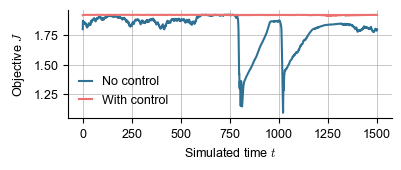

In [36]:
fig, ax = plt.subplots(figsize=(page_width/2, page_width/6))
ax.plot(objective_no_control, label='No control')
ax.plot(objective_with_control, label='With control')
ax.set(ylabel='Objective $J$', xlabel='Simulated time $t$')
ax.legend()

The angles are continuously adjusted over time:

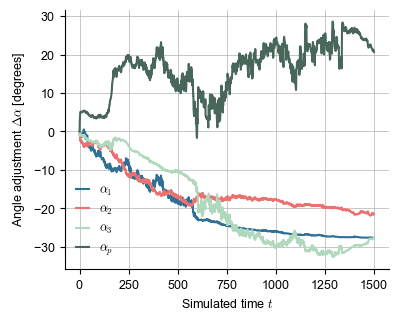

In [37]:
fig, ax = plt.subplots(figsize=(page_width/2, 0.4*page_width))
ax.plot((torch.stack(angles)-torch.stack(angles)[0]) * 180 / torch.pi, label=[r'$\alpha_1$', r'$\alpha_2$', r'$\alpha_3$', r'$\alpha_p$'])
ax.set(ylabel=r'Angle adjustment $\Delta \alpha$ [degrees]', xlabel='Simulated time $t$')
ax.legend()

Our publication plots clips the adjustment period:

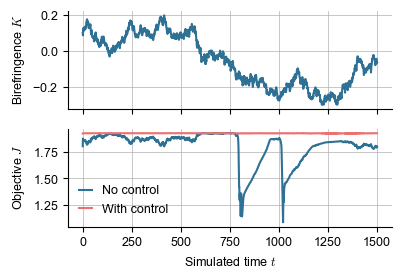

In [44]:
fig, axs = plt.subplots(nrows=2, figsize=(page_width/2, page_width/3), sharex=True)
axs[0].plot(K)
axs[0].set(ylabel='Birefringence $K$')

axs[1].plot(objective_no_control, label='No control')
axs[1].plot(objective_with_control, label='With control')
axs[1].set(ylabel='Objective $J$', xlabel='Simulated time $t$')
axs[1].legend()